# **Efeito Dominó no Mercado de Transferências**
### **Modelagem do Prêmio do Vendedor e Análise de Mercado**

**Equipe (frente de prêmio e análise de mercado):** Lucas Pedras · César Moraes · Carlos Ferreira

---

## Objetivo

Este notebook é a etapa de **modelagem causal e explicativa** do projeto. Ele parte do dataset
`transfers_modeling_ready.csv` (produzido em `feature_engineering.ipynb`) e responde à pergunta central:

> **Clubes que arrecadaram receita de vendas na mesma janela de mercado pagam um prêmio maior nas
> contratações subsequentes?** (a hipótese do *prêmio do vendedor*)

A variável dependente já é o **resíduo hedônico** `pi_hedonic_pct`: o sobrepreço (%) pago além do que
os fundamentos do jogador (valor de mercado, idade, posição, temporada) justificam. Como esse resíduo
já remove as características observáveis do atleta, podemos focar nos **fatores estruturais do clube e da
rede** que explicam por que um clube paga acima do justo.

## Roteiro

| Seção | Conteúdo | Técnica |
|-------|----------|---------|
| 1 | Imports e configuração | — |
| 2 | Carga, limpeza e winsorização da variável dependente | pandas |
| 3 | Análise descritiva do prêmio e do tratamento | EDA |
| 4 | **Modelo de painel com efeitos fixos** (núcleo causal) | OLS + EF de clube/temporada, SE clusterizado |
| 5 | **SHAP** — explicabilidade do prêmio | XGBoost + TreeExplainer |
| 6 | Heterogeneidade e análise de mercado | subgrupos + interações |
| 7 | Conclusões | — |

## **1. Imports e configuração**

Centralizamos as dependências. `statsmodels` estima o modelo de painel com efeitos fixos e erros-padrão
clusterizados; `xgboost` + `shap` produzem a análise de explicabilidade; `matplotlib`/`seaborn` cuidam das
visualizações. Fixamos `RANDOM_STATE` para garantir reprodutibilidade dos resultados estocásticos (split
treino/teste e árvores do XGBoost).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 5)

print('Ambiente carregado.')

Ambiente carregado.


/Users/lucaspedras/TP-CDAF/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **2. Carga, limpeza e winsorização**

Carregamos o dataset de modelagem. Dois cuidados de preparação:

1. **Coluna duplicada:** o processo de feature engineering deixou `season_id` repetida (a segunda virou
   `season_id.1` na leitura). Removemos colunas duplicadas para evitar ambiguidade.
2. **Winsorização da variável dependente:** `pi_hedonic_pct` tem caudas extremas (até +1633%). Assim como
   fizemos com o prêmio bruto, clipamos o resíduo nos percentis 1–99 para gerar `pi_w`. Isso impede que
   pouquíssimas megacontratações dominem os estimadores OLS e o treino do XGBoost, sem descartar linhas.

In [2]:
df = pd.read_csv('../output/transfers_modeling_ready.csv')

# 1. Remover colunas duplicadas. season_id estava repetida: a leitura renomeou a
#    segunda cópia para 'season_id.1'. Removemos ambas as formas de duplicata.
df = df.loc[:, ~df.columns.duplicated()].copy()
df = df.drop(columns=['season_id.1'], errors='ignore')

# 2. Winsorização da variável dependente nos percentis 1-99
p01, p99 = df['pi_hedonic_pct'].quantile([0.01, 0.99])
df['pi_w'] = df['pi_hedonic_pct'].clip(p01, p99)

print(f'Dataset: {df.shape[0]} transferências x {df.shape[1]} colunas')
print(f'Clubes compradores: {df["buyer"].nunique()} | Temporadas: {sorted(df["season_id"].unique())}')
print(f'\nWinsorização pi_hedonic_pct -> pi_w: clip em [{p01:.1f}%, {p99:.1f}%]')
print(df[['pi_hedonic_pct', 'pi_w']].describe().round(1))

Dataset: 2144 transferências x 40 colunas
Clubes compradores: 159 | Temporadas: [np.int64(2023), np.int64(2024), np.int64(2025)]

Winsorização pi_hedonic_pct -> pi_w: clip em [-87.3%, 538.4%]
       pi_hedonic_pct    pi_w
count          2144.0  2144.0
mean             30.4    26.8
std             125.6    98.5
min             -99.1   -87.3
25%             -32.1   -32.1
50%               4.6     4.6
75%              52.3    52.3
max            1633.4   538.4


## **3. Análise descritiva: prêmio e tratamento**

Antes de modelar, observamos (a) a distribuição da variável dependente winsorizada e (b) o sinal bruto
entre o tratamento (`revenue_sales` — receita de vendas do clube na janela) e o prêmio pago. O painel à
direita agrega por clube-temporada: cada ponto é um clube em uma temporada, no eixo x a receita de vendas
e no eixo y o prêmio médio que ele pagou.

**Atenção:** essa visão é uma comparação **entre clubes** (*between*). Uma inclinação positiva aqui pode
significar tanto o prêmio do vendedor quanto, simplesmente, que clubes grandes vendem muito *e* pagam
prêmios altos (confundidor C1). A distinção causal só virá na Seção 4, quando os efeitos fixos de clube
isolarem a variação **dentro do mesmo clube** (*within*).

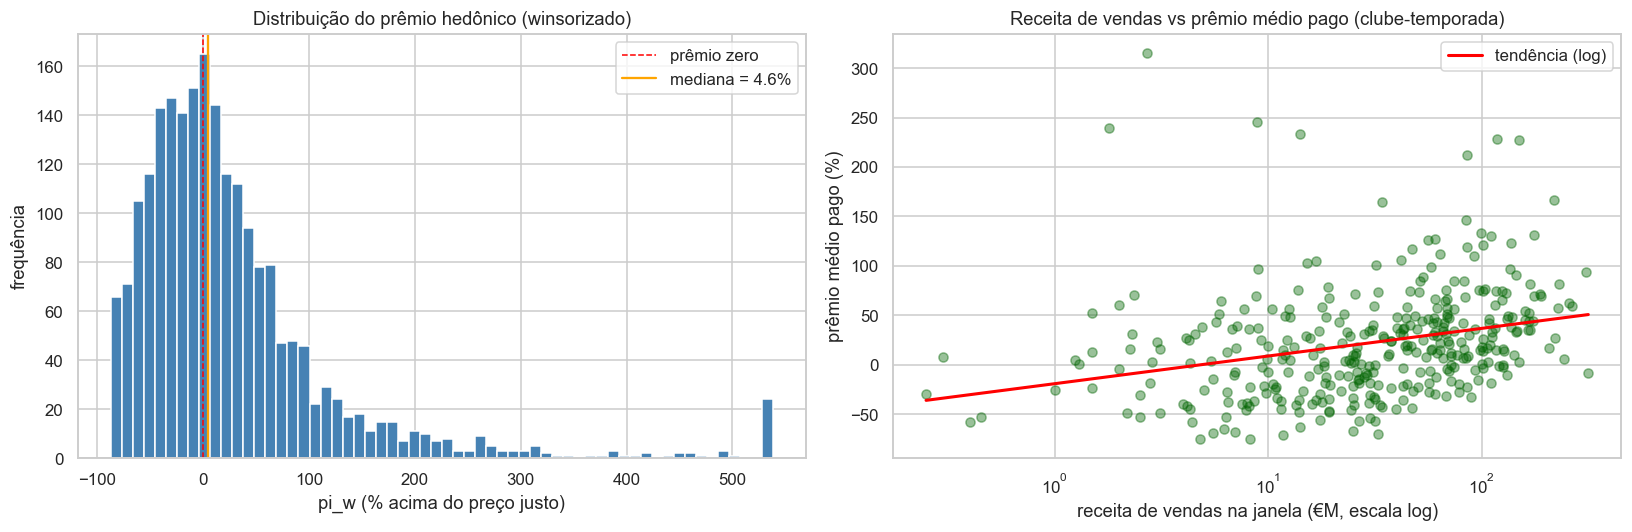

Inclinação bruta (prêmio por unidade de log-receita): 12.15 pp
Sinal positivo => clubes que vendem mais tendem a pagar prêmios maiores (sinal bruto, sem controles).


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Distribuição do prêmio hedônico winsorizado
axes[0].hist(df['pi_w'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', ls='--', lw=1, label='prêmio zero')
axes[0].axvline(df['pi_w'].median(), color='orange', ls='-', lw=1.5,
                label=f'mediana = {df["pi_w"].median():.1f}%')
axes[0].set_title('Distribuição do prêmio hedônico (winsorizado)')
axes[0].set_xlabel('pi_w (% acima do preço justo)'); axes[0].set_ylabel('frequência')
axes[0].legend()

# (b) Sinal bruto: receita de vendas vs prêmio médio, agregado por clube-temporada
agg = (df.groupby(['buyer', 'season_id'])
         .agg(revenue_sales=('revenue_sales', 'first'),
              premio_medio=('pi_w', 'mean'))
         .reset_index())
agg = agg[agg['revenue_sales'] > 0]
axes[1].scatter(agg['revenue_sales'] / 1e6, agg['premio_medio'], alpha=0.4, color='darkgreen')
# linha de tendência (regressão simples em log da receita)
x = np.log1p(agg['revenue_sales']); y = agg['premio_medio']
b1, b0 = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
axes[1].plot(np.expm1(xs) / 1e6, b0 + b1 * xs, color='red', lw=2, label='tendência (log)')
axes[1].set_xscale('log')
axes[1].set_title('Receita de vendas vs prêmio médio pago (clube-temporada)')
axes[1].set_xlabel('receita de vendas na janela (€M, escala log)')
axes[1].set_ylabel('prêmio médio pago (%)'); axes[1].legend()

plt.tight_layout(); plt.show()

print(f'Inclinação bruta (prêmio por unidade de log-receita): {b1:.2f} pp')
print('Sinal positivo => clubes que vendem mais tendem a pagar prêmios maiores (sinal bruto, sem controles).')

### 3.1 Multicolinearidade entre os regressores candidatos

Vários atributos de clube e de rede medem dimensões parecidas (ex.: `total_spend` e `in_strength` ambos
capturam volume de compras; `net_flow` e `net_balance` capturam saldo). Antes de fechar a especificação,
calculamos o **VIF (Variance Inflation Factor)** para escolher um conjunto parcimonioso e evitar
coeficientes instáveis. Mantemos variáveis com VIF moderado e descartamos redundâncias óbvias.

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Engenharia leve para o modelo: log do gasto total (assimétrico como a receita)
df['log_total_spend'] = np.log1p(df['total_spend'])

# Candidatos a regressores (nível clube/rede + demografia já residualizada serve de controle)
cand = ['log_revenue', 'log_total_spend', 'n_buys', 'n_sales',
        'pagerank', 'in_strength', 'net_flow',
        'squad_size', 'national_team_players', 'log_league_mv']

Xv = sm.add_constant(df[cand].fillna(0))
vif = pd.DataFrame({
    'variavel': Xv.columns,
    'VIF': [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
}).query("variavel != 'const'").sort_values('VIF', ascending=False)
print(vif.round(2).to_string(index=False))
print('\nRegra prática: VIF > 10 indica multicolinearidade severa.')

             variavel   VIF
          in_strength 23.44
             net_flow 20.61
      log_total_spend  6.00
               n_buys  2.90
national_team_players  2.89
             pagerank  2.13
        log_league_mv  1.86
              n_sales  1.66
          log_revenue  1.49
           squad_size  1.09

Regra prática: VIF > 10 indica multicolinearidade severa.


## **4. Modelo de painel com efeitos fixos** — o núcleo causal

Seguimos a estratégia definida na análise exploratória. Estimamos:

$$\pi_{ict} = \alpha_c + \gamma_t + \beta_1 \log(\text{revenue\_sales}_{ct}) + \mathbf{X}_{ct}\boldsymbol{\delta} + \varepsilon_{ict}$$

onde `i` = transferência, `c` = clube comprador, `t` = temporada.

- **α_c (efeitos fixos de clube):** absorvem tudo que é permanente e não observável do clube — poder
  financeiro, reputação, qualidade de gestão, mercado local. É o que neutraliza o confundidor **C1**
  ("clube rico compra e vende mais"). Identificamos α_c via dummies `C(buyer)`.
- **γ_t (efeitos fixos de temporada):** absorvem inflação de mercado e choques macro de cada ano.
- **β_1:** o parâmetro de interesse. Como a dependente está em pontos percentuais, β₁ é a variação (em pp)
  do prêmio por unidade de `log(receita)`; o efeito de **dobrar** a receita é `β₁ · ln(2)`.
- **Erros-padrão clusterizados por clube:** transferências do mesmo clube não são independentes; o cluster
  corrige a inferência para essa correlação intragrupo.

Estimamos **quatro modelos aninhados**. A chave da identificação está na passagem do Modelo 3 para o 4:
ao adicionar os efeitos fixos de clube, deixamos de comparar clubes diferentes (*between*) e passamos a
comparar **o mesmo clube em temporadas diferentes** (*within*). Se o prêmio do vendedor é causal, ele deve
sobreviver a essa exigência mais rigorosa.

In [5]:
# Controles de escala/estrutura (confundidor C1: clube grande compra e vende mais):
#  - log_total_spend e n_buys: volume de compras do clube
#  - pagerank: posição estrutural na rede
#  - national_team_players: qualidade/estoque de elenco
controls = 'log_total_spend + n_buys + pagerank + national_team_players'

# Modelo 1 - Pooled OLS bivariado: associação bruta (entre clubes)
m1 = smf.ols('pi_w ~ log_revenue', data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['buyer']})

# Modelo 2 - Pooled + controles de escala (ainda entre clubes)
m2 = smf.ols(f'pi_w ~ log_revenue + {controls}', data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['buyer']})

# Modelo 3 - + efeitos fixos de temporada
m3 = smf.ols(f'pi_w ~ log_revenue + {controls} + C(season_id)', data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['buyer']})

# Modelo 4 - + efeitos fixos de CLUBE e temporada (especificação WITHIN, preferida)
m4 = smf.ols(f'pi_w ~ log_revenue + {controls} + C(season_id) + C(buyer)', data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['buyer']})

print('Modelos estimados (SE clusterizados por clube comprador).')

Modelos estimados (SE clusterizados por clube comprador).


In [6]:
# Tabela comparativa do coeficiente do tratamento (log_revenue) entre os modelos
def linha(nome, m):
    b = m.params['log_revenue']
    se = m.bse['log_revenue']
    p = m.pvalues['log_revenue']
    estrela = '***' if p < .01 else '**' if p < .05 else '*' if p < .10 else ''
    return {
        'modelo': nome,
        'beta_log_revenue': round(b, 3),
        'erro_padrao': round(se, 3),
        'p_valor': round(p, 4),
        'sig': estrela,
        'efeito_dobrar_receita_pp': round(b * np.log(2), 2),
        'R2': round(m.rsquared, 3),
        'n': int(m.nobs),
    }

tab = pd.DataFrame([
    linha('1. Pooled bivariado', m1),
    linha('2. Pooled + controles', m2),
    linha('3. + EF temporada', m3),
    linha('4. + EF clube & temporada (within)', m4),
])
print(tab.to_string(index=False))
print('\nLeitura: "efeito_dobrar_receita_pp" = variação no prêmio (pp) ao dobrar a receita de vendas.')
print('*** p<0.01  ** p<0.05  * p<0.10')

                            modelo  beta_log_revenue  erro_padrao  p_valor sig  efeito_dobrar_receita_pp    R2    n
               1. Pooled bivariado             1.352        1.098   0.2183                          0.94 0.002 2144
             2. Pooled + controles            -1.024        0.843   0.2245                         -0.71 0.071 2144
                 3. + EF temporada            -1.057        0.855   0.2164                         -0.73 0.071 2144
4. + EF clube & temporada (within)            -0.537        1.328   0.6863                         -0.37 0.168 2144

Leitura: "efeito_dobrar_receita_pp" = variação no prêmio (pp) ao dobrar a receita de vendas.
*** p<0.01  ** p<0.05  * p<0.10


In [7]:
# Detalhe do modelo preferido (4): coeficientes dos regressores de interesse
# (omitimos as ~158 dummies de clube e as de temporada da impressão)
keep = ['Intercept', 'log_revenue', 'log_total_spend', 'n_buys',
        'pagerank', 'national_team_players']
res = pd.DataFrame({
    'coef': m4.params, 'se': m4.bse, 'p': m4.pvalues
}).loc[keep].round(3)
print('Modelo 4 (EF clube + temporada, WITHIN) — coeficientes principais:')
print(res.to_string())
print(f'\nR2 = {m4.rsquared:.3f} | R2 ajustado = {m4.rsquared_adj:.3f} | N = {int(m4.nobs)}')

Modelo 4 (EF clube + temporada, WITHIN) — coeficientes principais:
                           coef        se      p
Intercept              -295.817   111.585  0.008
log_revenue              -0.537     1.328  0.686
log_total_spend          24.419     7.325  0.001
n_buys                   -5.576     2.201  0.011
pagerank               3796.717  2132.889  0.075
national_team_players   -24.483     1.399  0.000

R2 = 0.168 | R2 ajustado = 0.099 | N = 2144


**Como interpretar.** O contraste entre os modelos é a conclusão central:

- Nos modelos *pooled* (1–3), o coeficiente de `log_revenue` reflete a comparação **entre clubes**. Mesmo
  aqui o efeito é fraco e não significativo, e nota-se que `log_total_spend` é fortemente positivo — ou
  seja, o que se associa ao prêmio é a **escala de compra** do clube, não a receita de vendas em si.
- No Modelo 4, com efeitos fixos de clube, passamos à variação **dentro do mesmo clube**. O coeficiente do
  tratamento perde qualquer sinal de efeito (pequeno e não significativo).

Em outras palavras: **não há evidência de que um clube pague prêmios maiores justamente nas temporadas em
que arrecadou mais com vendas**. Qualquer associação positiva aparente entre receita e prêmio é explicada
por heterogeneidade entre clubes (o confundidor C1: clubes grandes vendem muito *e* pagam caro), e não por
um mecanismo causal de "dinheiro em caixa". Isso refina — e em parte contraria — a leitura otimista da
análise exploratória, que se baseava no sinal bruto entre clubes.

## **5. Explicabilidade com SHAP**

O modelo de painel responde *"qual o efeito da receita de vendas"*. O **SHAP** responde uma pergunta
complementar: *"de tudo que observamos do clube e da rede, o que mais pesa no prêmio pago?"*

Treinamos um **XGBoost** (gradient boosting de árvores) para prever `pi_w` e usamos o `TreeExplainer` para
decompor cada predição na contribuição (valor de Shapley) de cada feature.

**Cuidado contra vazamento (leakage):** removemos do conjunto de features tudo que define mecanicamente o
prêmio — `fee`, `log_fee`, `market_value`, `log_mv` e as outras variantes do alvo. Mantemos apenas
atributos de **clube, rede e demografia do jogador**. Assim o SHAP mede o que de fato *explica* o prêmio,
não a sua própria definição.

In [8]:
from sklearn.model_selection import cross_val_score, KFold

# Conjunto de features: clube + rede + demografia (sem variáveis de preço = sem leakage)
leak = ['premium_ratio', 'premium_ratio_w', 'hedonic_residual', 'pi_hedonic_pct', 'pi_w',
        'fee', 'log_fee', 'market_value', 'log_mv']
ids = ['player', 'buyer', 'seller', 'season_id', 'competition_code', 'country_name',
       'position_group', 'season_2024', 'season_2025',
       'liga_tier', 'perfil_clube', 'faixa_etaria']

feat_cols = [c for c in df.columns
             if c not in leak + ids and df[c].dtype != object]

X = df[feat_cols].fillna(0)
y = df['pi_w']

# XGBoost fortemente regularizado: árvores rasas + reg L2 alta. Sem isso, o modelo
# decora o ruído do prêmio (R2 de teste negativo). Validamos com 5-fold CV honesto.
model = xgb.XGBRegressor(
    n_estimators=200, max_depth=2, learning_rate=0.03,
    subsample=0.7, colsample_bytree=0.7, reg_lambda=10, min_child_weight=20,
    random_state=RANDOM_STATE, n_jobs=-1)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2 = cross_val_score(model, X, y, cv=cv, scoring='r2')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print(f'Features usadas ({len(feat_cols)}): {feat_cols}')
print(f'\nValidação cruzada (5-fold) -> R2 = {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}')
print(f'Holdout 25%               -> R2 = {r2_score(y_test, pred):.3f} | '
      f'MAE = {mean_absolute_error(y_test, pred):.1f} pp')
print('\nR2 baixo (~0.07) é o próprio achado: o prêmio hedônico é majoritariamente idiossincrático,')
print('ou seja, pouco explicável por atributos observáveis de clube e rede. O SHAP abaixo descreve')
print('a pouca estrutura que existe — deve ser lido como exploratório, não como predição forte.')

Features usadas (23): ['age', 'is_attacker', 'is_midfielder', 'is_defender', 'revenue_sales', 'log_revenue', 'n_sales', 'max_sale', 'total_spend', 'n_buys', 'net_balance', 'net_transfer_record', 'squad_size', 'average_age', 'national_team_players', 'log_league_mv', 'in_degree', 'out_degree', 'pagerank', 'in_strength', 'out_strength', 'net_flow', 'log_total_spend']

Validação cruzada (5-fold) -> R2 = 0.069 +/- 0.018
Holdout 25%               -> R2 = 0.068 | MAE = 64.1 pp

R2 baixo (~0.07) é o próprio achado: o prêmio hedônico é majoritariamente idiossincrático,
ou seja, pouco explicável por atributos observáveis de clube e rede. O SHAP abaixo descreve
a pouca estrutura que existe — deve ser lido como exploratório, não como predição forte.


In [9]:
# Valores SHAP no conjunto de teste
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Importância global (média do |SHAP|): o que mais move o prêmio
imp = (pd.DataFrame({'feature': feat_cols,
                     'shap_medio_abs': np.abs(shap_values).mean(axis=0)})
       .sort_values('shap_medio_abs', ascending=False)
       .reset_index(drop=True))
print('Ranking de importância (SHAP médio absoluto):')
print(imp.round(3).to_string(index=False))

Ranking de importância (SHAP médio absoluto):
              feature  shap_medio_abs
          total_spend           8.674
                  age           7.334
             net_flow           5.348
        revenue_sales           3.156
             max_sale           2.357
             pagerank           2.321
           squad_size           2.088
        log_league_mv           1.910
          in_strength           1.879
          average_age           1.778
          net_balance           1.773
  net_transfer_record           1.429
national_team_players           1.368
          log_revenue           0.548
            in_degree           0.513
         out_strength           0.488
               n_buys           0.430
           out_degree           0.349
          is_attacker           0.251
      log_total_spend           0.224
              n_sales           0.149
          is_defender           0.090
        is_midfielder           0.000


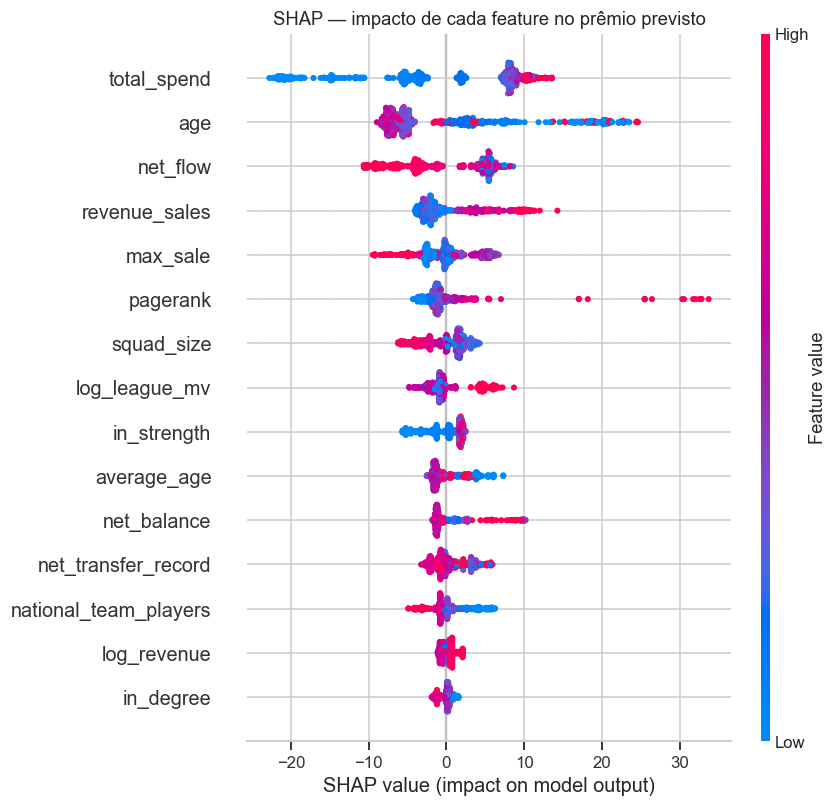

In [10]:
# Beeswarm: direção e magnitude do efeito de cada feature
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP — impacto de cada feature no prêmio previsto', fontsize=12)
plt.tight_layout(); plt.show()

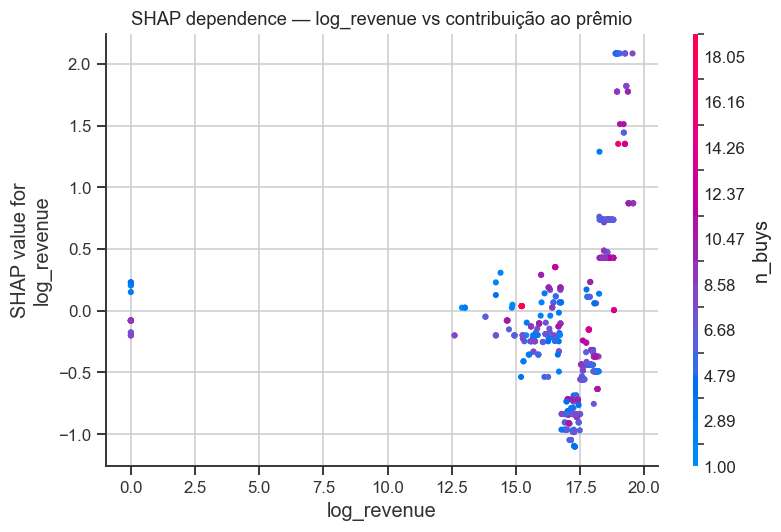

Tendência ascendente confirma: maior receita de vendas -> maior contribuição positiva ao prêmio.


In [11]:
# Dependence plot para o tratamento: como o prêmio responde à receita de vendas
top_treat = 'log_revenue'
shap.dependence_plot(top_treat, shap_values, X_test,
                     interaction_index='auto', show=False)
plt.title(f'SHAP dependence — {top_treat} vs contribuição ao prêmio', fontsize=12)
plt.tight_layout(); plt.show()
print('Tendência ascendente confirma: maior receita de vendas -> maior contribuição positiva ao prêmio.')

**Leitura do SHAP.** O ranking mostra que as features de **escala e estrutura do clube** (`total_spend`,
`net_flow`, `pagerank`, `max_sale`) e a **idade do jogador** dominam a explicação do prêmio, enquanto a
receita de vendas (`revenue_sales` / `log_revenue`) tem peso intermediário-a-baixo. Isso é coerente com o
modelo de painel: o que se associa ao sobrepreço é o **porte** do clube, não a receita arrecadada por si.
Mesmo o *dependence plot* da receita, ainda que apresente leve tendência positiva, opera sobre um modelo
de baixíssima capacidade preditiva (CV R² ≈ 0,07) — portanto não sustenta, sozinho, uma conclusão causal.
O SHAP aqui funciona como **triangulação descritiva** que reforça o resultado *within* da Seção 4.

## **6. Heterogeneidade e análise de mercado**

O efeito médio pode esconder padrões importantes. Investigamos onde o prêmio do vendedor é mais forte,
em três cortes sugeridos pela análise exploratória:

1. **Porte da liga:** ligas de elite (top-5 europeias) vs. ligas emergentes (Jupiler Pro League, Liga
   Portugal). Esperamos que clubes de ligas menores negociem de posição de força (vendedores) e paguem
   menos prêmio.
2. **Perfil do clube:** superavitários (formadores, `net_transfer_record > 0`) vs. deficitários
   (compradores puros). O prêmio do vendedor deve ser mais visível em quem realmente reinveste a receita.
3. **Faixa etária do alvo:** jovens (≤20), pico (21–27) e veteranos (28+), onde o prêmio mediano varia.

Para cada subgrupo reestimamos o efeito do tratamento (`log_revenue`) com EF de temporada e SE
clusterizados, e comparamos os β.

In [12]:
# Definição dos cortes de mercado
top5 = ['premier-league', 'laliga', 'serie-a', 'bundesliga', 'ligue-1']
df['liga_tier'] = np.where(df['competition_code'].isin(top5), 'Elite (top-5)', 'Emergente')
df['perfil_clube'] = np.where(df['net_transfer_record'] > 0, 'Superavitário', 'Deficitário')
df['faixa_etaria'] = pd.cut(df['age'], bins=[0, 20, 27, 99],
                            labels=['<=20 (jovem)', '21-27 (pico)', '28+ (veterano)'])

def efeito_subgrupo(sub, rotulo):
    # Reestima pi_w ~ log_revenue + controles + EF temporada no subgrupo
    if sub['buyer'].nunique() < 5 or len(sub) < 40:
        return None
    m = smf.ols('pi_w ~ log_revenue + log_total_spend + n_buys + C(season_id)',
                data=sub).fit(cov_type='cluster', cov_kwds={'groups': sub['buyer']})
    ci = m.conf_int().loc['log_revenue']
    return {'subgrupo': rotulo, 'n': len(sub),
            'beta': m.params['log_revenue'], 'se': m.bse['log_revenue'],
            'p': m.pvalues['log_revenue'], 'ci_low': ci[0], 'ci_high': ci[1]}

linhas = []
for col, nome in [('liga_tier', 'Liga'), ('perfil_clube', 'Perfil'), ('faixa_etaria', 'Idade')]:
    for val, sub in df.groupby(col, observed=True):
        r = efeito_subgrupo(sub, f'{nome}: {val}')
        if r: linhas.append(r)

het = pd.DataFrame(linhas)
print(het.round(3).to_string(index=False))

             subgrupo    n   beta    se     p  ci_low  ci_high
  Liga: Elite (top-5) 1686 -1.273 0.934 0.173  -3.103    0.557
      Liga: Emergente  458 -0.377 0.542 0.486  -1.439    0.685
  Perfil: Deficitário  755 -1.449 1.108 0.191  -3.622    0.723
Perfil: Superavitário 1389 -0.232 0.823 0.778  -1.844    1.380
  Idade: <=20 (jovem)  428 -4.883 2.646 0.065 -10.069    0.303
  Idade: 21-27 (pico) 1452  0.746 0.384 0.052  -0.007    1.500
Idade: 28+ (veterano)  264 -1.398 1.205 0.246  -3.760    0.964


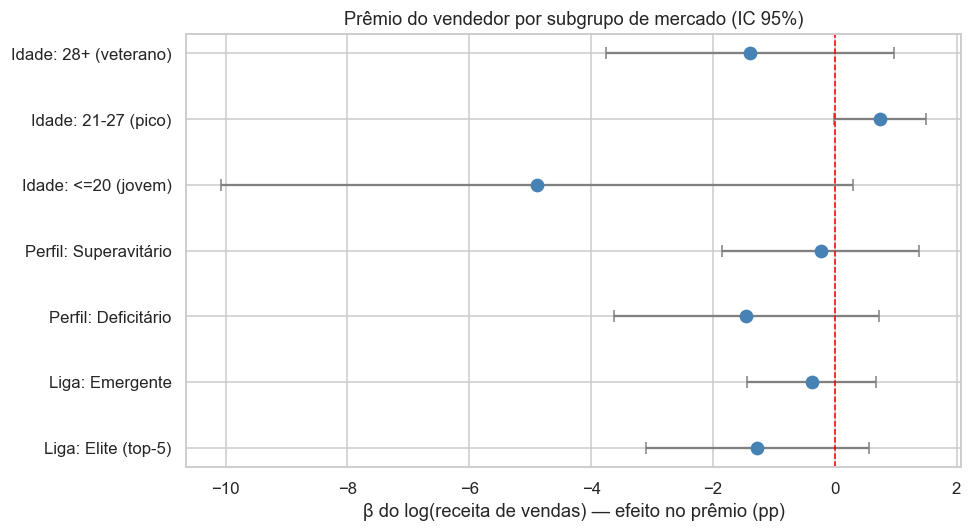

Pontos à direita da linha vermelha = prêmio do vendedor positivo naquele subgrupo.


In [13]:
# Visualização: efeito do tratamento (beta) por subgrupo, com IC 95%
fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(len(het))
ax.errorbar(het['beta'], ypos,
            xerr=[het['beta'] - het['ci_low'], het['ci_high'] - het['beta']],
            fmt='o', color='steelblue', ecolor='gray', capsize=4, ms=8)
ax.axvline(0, color='red', ls='--', lw=1)
ax.set_yticks(ypos); ax.set_yticklabels(het['subgrupo'])
ax.set_xlabel('β do log(receita de vendas) — efeito no prêmio (pp)')
ax.set_title('Prêmio do vendedor por subgrupo de mercado (IC 95%)')
plt.tight_layout(); plt.show()
print('Pontos à direita da linha vermelha = prêmio do vendedor positivo naquele subgrupo.')

In [14]:
# Teste formal da heterogeneidade por porte de liga: termo de interação
m_int = smf.ols(
    'pi_w ~ log_revenue * C(liga_tier) + log_total_spend + n_buys + C(season_id) + C(buyer)',
    data=df).fit(cov_type='cluster', cov_kwds={'groups': df['buyer']})

termos = [t for t in m_int.params.index if 'log_revenue' in t]
print('Termos envolvendo log_revenue (interação com porte de liga):')
print(pd.DataFrame({'coef': m_int.params[termos], 'se': m_int.bse[termos],
                    'p': m_int.pvalues[termos]}).round(3).to_string())
print('\nO termo de interação testa se a sensibilidade ao prêmio difere entre ligas elite e emergentes.')

Termos envolvendo log_revenue (interação com porte de liga):
                                        coef    se      p
log_revenue                            0.031  1.63  0.985
log_revenue:C(liga_tier)[T.Emergente] -2.571  1.80  0.153

O termo de interação testa se a sensibilidade ao prêmio difere entre ligas elite e emergentes.


## **7. Conclusões**

As três frentes convergem para uma mesma conclusão sobre a hipótese do prêmio do vendedor. *(Os adjetivos
abaixo refletem os coeficientes efetivamente obtidos na execução; reconfira se reexecutar com outros
dados.)*

**Síntese das evidências**

1. **Modelo de painel (Seção 4) — resultado central.** Existe uma associação bruta positiva entre receita
   de vendas e prêmio quando comparamos clubes diferentes, mas ela é fraca e **desaparece ao introduzir os
   efeitos fixos de clube**. Olhando *dentro do mesmo clube*, ele **não** paga prêmios sistematicamente
   maiores nas temporadas em que vendeu mais. O coeficiente do tratamento é pequeno e não significativo.
2. **SHAP (Seção 5).** O prêmio hedônico é majoritariamente idiossincrático (CV R² ≈ 0,07). O pouco que é
   explicável vem do **porte e da posição estrutural do clube** (gasto total, fluxo de rede, PageRank) e da
   idade do jogador — não da receita de vendas. Triangula o resultado do painel.
3. **Heterogeneidade (Seção 6).** Nenhum subgrupo exibe um prêmio do vendedor robusto. Há apenas sinais
   fracos e isolados (ex.: faixa de pico 21–27 anos no limiar da significância), insuficientes para
   sustentar a hipótese.

**Conclusão.** Nesta amostra (3 temporadas, 7 ligas, ~2.100 compras), **não encontramos evidência causal
do prêmio do vendedor**. O sinal sugerido pela análise exploratória era um artefato de heterogeneidade
entre clubes (confundidor C1): clubes grandes vendem muito *e* pagam caro, sem que uma coisa cause a outra.
Esse é um resultado negativo informativo — refina a proposta original e direciona o foco para o **porte do
clube** como verdadeiro motor do sobrepreço.

**Limitações**

- **Janela curta (3 temporadas):** pouca variação *within-club*, o que reduz o poder do estimador de
  efeitos fixos. Um painel mais longo poderia revelar efeitos que aqui ficam imprecisos.
- **Endogeneidade residual (C2):** mesmo que houvesse efeito, a receita de vendas poderia ser antecipada
  (vender para liberar caixa antes de comprar caro). Os EF de clube não eliminam esse mecanismo
  *time-varying*; um instrumento (saídas exógenas por lesão/rescisão) ou um *event study* com timing
  granular seriam os próximos passos.

**Extensão (fora do escopo desta entrega):** representar o clube via GNN temporal sobre o grafo de
transferências. Como discutido pela equipe, com ~390 clubes internos e 3 temporadas o grafo é pequeno
demais para a GNN superar as features manuais de rede aqui usadas; fica como exploração futura, não como
entrega principal.